In [1]:
import os
os.environ["SIGRUN_IO_ENGINE"] = "false"

import logging
logging.basicConfig(level=logging.INFO)

from sigrun import virgo as sv
import virgo as _virgo
VIRGO_TOKEN = "ltIIImLNjbF4V6Qk"
_virgo.init("virgo", VIRGO_TOKEN)
sv.init("virgo", VIRGO_TOKEN)
import datetime

import sigrun
from sigrun import polars as pl
from sigrun.polars import col as c
from sigrun.workflow import factor

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
from scipy.stats import norm
from scipy.optimize import minimize
import warnings

In [12]:
from_date = datetime.date(2024, 7, 10)
today = datetime.date(2024, 7, 18)
data = pl.DataFrame({
    "symbol": ["A"] * 100 + ["B"] * 100,
    "date": np.repeat(np.arange(100), 2),
    "time": np.tile([f"{i:02d}:00" for i in range(100)], 2),
    "close": np.random.lognormal(0.0005, 0.02, 200).cumprod()  # 模拟股价
})
lf = data.lazy()
print(data)

# def is_stationary(series, significance = 0.05):
#     result = adfuller(series)
#     p_value = result[1]
#     return p_value<significance

# def fit_garch_predict_volatility(returns):
#     model = arch_model(returns, vol="GARCH", p=1, q=1, dist="Normal")
#     res = model.fit(disp='off')
#     forecast = res.forecast(horizon=1)
#     volatility_forecast = np.sqrt(forecast.variance.values[-1][0])
#     return volatility_forecast

def fit_distribution(returns):
    mu, sigma = norm.fit(returns)
    return mu, sigma
print(fit_distribution(data["close"]))

def probability_growth(mu, sigma, last_return):
    # P(X > last_return | X ~ N(mu, sigma^2))
    z_score = (last_return - mu) / sigma
    prob = 1 - norm.cdf(z_score)
    return prob
mu, sigma = fit_distribution(data["close"])
last_return = data["close"][-1]
prob = probability_growth(mu, sigma, last_return)
print(prob)


def process_symbol(df_symbol: pl.DataFrame):
    returns = df_symbol["log_ret"].to_numpy()
    
    # if not is_stationary(returns):
    #     return None  # 不平稳则跳过
    
    try:
        # vol = fit_garch_predict_volatility(returns)
        mu, sigma = fit_distribution(returns)
        last_return = returns[-1]
        prob = probability_growth(mu, sigma, last_return)
        
        return {
            "symbol": df_symbol["symbol"][0],
            "predicted_prob": prob,
            # "forecasted_vol": vol
        }
    except Exception as e:
        print(f"Error processing {df_symbol['symbol'][0]}: {e}")
        return None
    
def price(from_date, today):
    lf_price = (sv.stock.bars("all", "30m", from_date=from_date, to_date=today)
            .filter((c("date")<today) | (((c("date")==today) & (c("time")<=36_000_000_000_000)))) #早上10点前数据
            #.with_columns(datetime=c("date")+c("time")).drop("date", "time")
            .select("symbol", "date", "time", "close", price_ret = c("close")/c("pre_close")-1)
            .with_columns((1+c("price_ret")).log().alias("log_ret"))
            .with_columns(c("time").cast(pl.Int64).cast(pl.Time))
        )
    return lf_price

pl.Config.set_tbl_rows(30)
lf_price = price(from_date, today)
lf_price.collect()

shape: (200, 4)
┌────────┬──────┬───────┬──────────┐
│ symbol ┆ date ┆ time  ┆ close    │
│ ---    ┆ ---  ┆ ---   ┆ ---      │
│ str    ┆ i64  ┆ str   ┆ f64      │
╞════════╪══════╪═══════╪══════════╡
│ A      ┆ 0    ┆ 00:00 ┆ 1.020742 │
│ A      ┆ 0    ┆ 01:00 ┆ 1.004452 │
│ A      ┆ 1    ┆ 02:00 ┆ 1.032264 │
│ A      ┆ 1    ┆ 03:00 ┆ 1.02023  │
│ A      ┆ 2    ┆ 04:00 ┆ 1.012199 │
│ A      ┆ 2    ┆ 05:00 ┆ 1.015062 │
│ A      ┆ 3    ┆ 06:00 ┆ 1.029223 │
│ A      ┆ 3    ┆ 07:00 ┆ 1.007318 │
│ A      ┆ 4    ┆ 08:00 ┆ 1.012881 │
│ A      ┆ 4    ┆ 09:00 ┆ 0.997945 │
│ A      ┆ 5    ┆ 10:00 ┆ 1.00445  │
│ A      ┆ 5    ┆ 11:00 ┆ 0.968418 │
│ A      ┆ 6    ┆ 12:00 ┆ 0.944979 │
│ A      ┆ 6    ┆ 13:00 ┆ 0.944076 │
│ A      ┆ 7    ┆ 14:00 ┆ 0.957365 │
│ …      ┆ …    ┆ …     ┆ …        │
│ B      ┆ 92   ┆ 85:00 ┆ 1.04994  │
│ B      ┆ 93   ┆ 86:00 ┆ 1.022394 │
│ B      ┆ 93   ┆ 87:00 ┆ 1.019519 │
│ B      ┆ 94   ┆ 88:00 ┆ 1.03479  │
│ B      ┆ 94   ┆ 89:00 ┆ 1.043444 │
│ B      ┆ 95   ┆ 90:0

symbol,date,time,close,price_ret,log_ret
str,datetime[ns],time,f64,f64,f64
"""000001.SZE""",2024-07-10 00:00:00,09:30:00,10.07,0.0,0.0
"""000001.SZE""",2024-07-10 00:00:00,10:00:00,10.13,0.005958,0.005941
"""000001.SZE""",2024-07-10 00:00:00,10:30:00,10.18,0.004936,0.004924
"""000001.SZE""",2024-07-10 00:00:00,11:00:00,10.18,0.0,0.0
"""000001.SZE""",2024-07-10 00:00:00,11:30:00,10.19,0.000982,0.000982
"""000001.SZE""",2024-07-10 00:00:00,13:30:00,10.14,-0.004907,-0.004919
"""000001.SZE""",2024-07-10 00:00:00,14:00:00,10.15,0.000986,0.000986
"""000001.SZE""",2024-07-10 00:00:00,14:30:00,10.14,-0.000985,-0.000986
"""000001.SZE""",2024-07-10 00:00:00,15:00:00,10.14,0.0,0.0


In [14]:
@factor
def hot_factors(date: datetime.date, time: datetime.time):
    
    today = date
    from_date = date - datetime.timedelta(days=5)
    
    lf_price = price(from_date, today).collect()

    results = []
    symbols = lf_price["symbol"].unique()

    for symbol in symbols:
        df_symbol = lf_price.filter(c("symbol")==symbol)
        result = process_symbol(df_symbol)
        if result:
            results.append(result)

    print(today)
    results = pl.DataFrame(results)
    return results.lazy()

alpha_fdf = sigrun.run(hot_factors, start_date="2024-07-18", end_date="2025-03-01", times=[datetime.time(10,0,0)])
alpha_fdf

  2025-07-10T14:12:42.054396165+08:00  INFO sigrun::run:262: enable dir cache

[1/2] 🔍  Building  lazyframes...


/tmp/ipykernel_97369/851951186.py:31: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (last_return - mu) / sigma


2024-07-18
2024-07-19
2024-07-22
2024-07-23
2024-07-24
2024-07-25
2024-07-26
2024-07-29
2024-07-30
2024-07-31
2024-08-01
2024-08-02
2024-08-05
2024-08-06
2024-08-07
2024-08-08
2024-08-09
2024-08-12
2024-08-13
2024-08-14
2024-08-15
2024-08-16
2024-08-19
2024-08-20
2024-08-21
2024-08-22
2024-08-23
2024-08-26
2024-08-27
2024-08-28
2024-08-29
2024-08-30
2024-09-02
2024-09-03
2024-09-04
2024-09-05
2024-09-06
2024-09-09
2024-09-10
2024-09-11
2024-09-12
2024-09-13
2024-09-18
2024-09-19
2024-09-20
2024-09-23
2024-09-24
2024-09-25
2024-09-26
2024-09-27
2024-09-30
2024-10-08
2024-10-09
2024-10-10
2024-10-11
2024-10-14
2024-10-15
2024-10-16
2024-10-17
2024-10-18
2024-10-21
2024-10-22
2024-10-23
2024-10-24
2024-10-25
2024-10-28
2024-10-29
2024-10-30
2024-10-31
2024-11-01
2024-11-04
2024-11-05
2024-11-06
2024-11-07
2024-11-08
2024-11-11
2024-11-12
2024-11-13
2024-11-14
2024-11-15
2024-11-18
2024-11-19
2024-11-20
2024-11-21
2024-11-22
2024-11-25
2024-11-26
2024-11-27
2024-11-28
2024-11-29
2024-12-02

✨  Done in 13 minutes


symbol,predicted_prob,date,time
str,f64,date,time
"""600970.SSE""",0.344378,2024-07-18,10:00:00
"""688702.SSE""",0.384033,2024-07-18,10:00:00
"""002546.SZE""",0.659913,2024-07-18,10:00:00
"""300242.SZE""",0.21035,2024-07-18,10:00:00
"""002978.SZE""",0.174273,2024-07-18,10:00:00
"""603968.SSE""",0.993684,2024-07-18,10:00:00
"""002940.SZE""",0.88608,2024-07-18,10:00:00
"""600136.SSE""",0.017294,2024-07-18,10:00:00
"""601881.SSE""",0.987454,2024-07-18,10:00:00


INFO:sailor_bt_client.entry:Job sailor-bt-remote-o7gfex is Pending
INFO:sailor_bt_client.entry:Job sailor-bt-remote-o7gfex is Running
INFO:sailor_bt_client.event_bt:bt meta : {"id":"a93af0a1f0f8","factor_name":"predicted_prob","time":"10:00:00","start_date":"2024-07-18","end_date":"2025-03-01","ret_type":"CLOSE","benchmark":{"universe":"500","method":"INDEX"},"lead_start_day":-5,"lag_end_day":15,"num_groups":7}


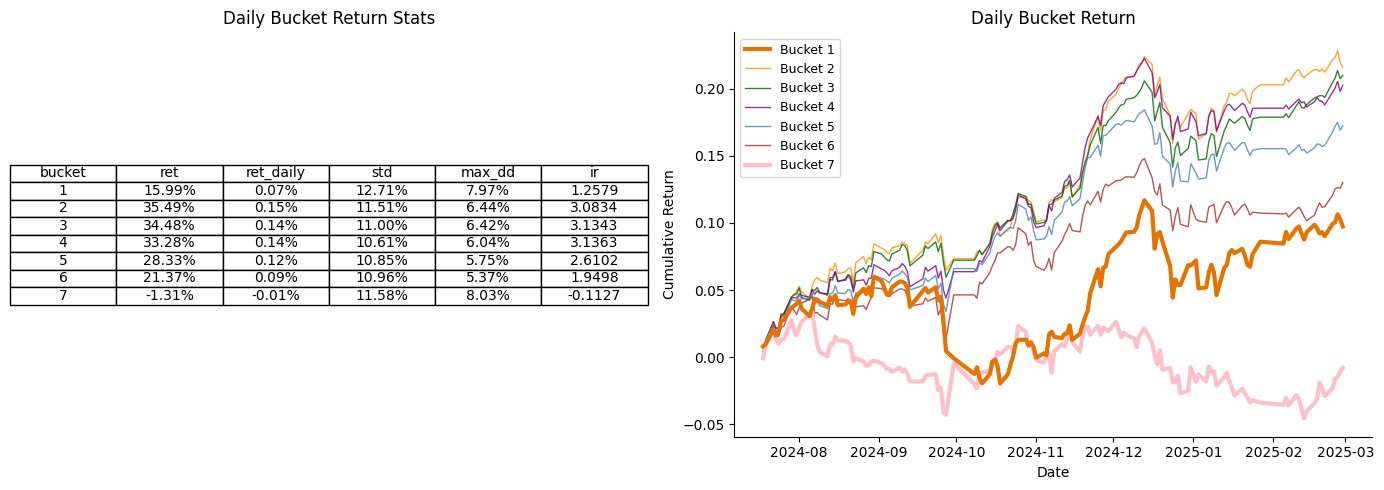

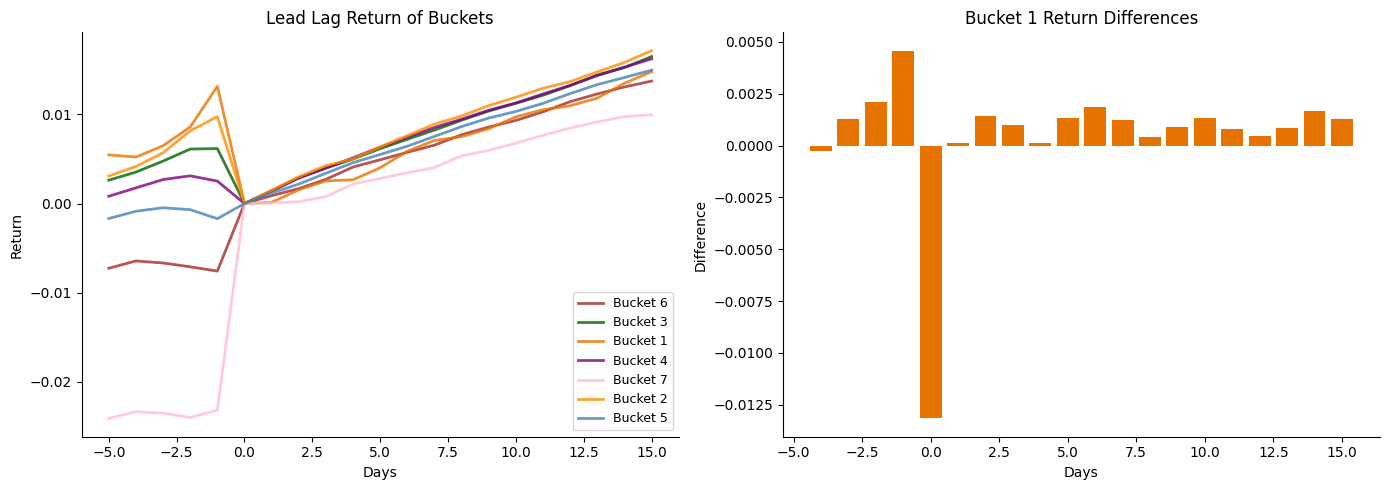

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


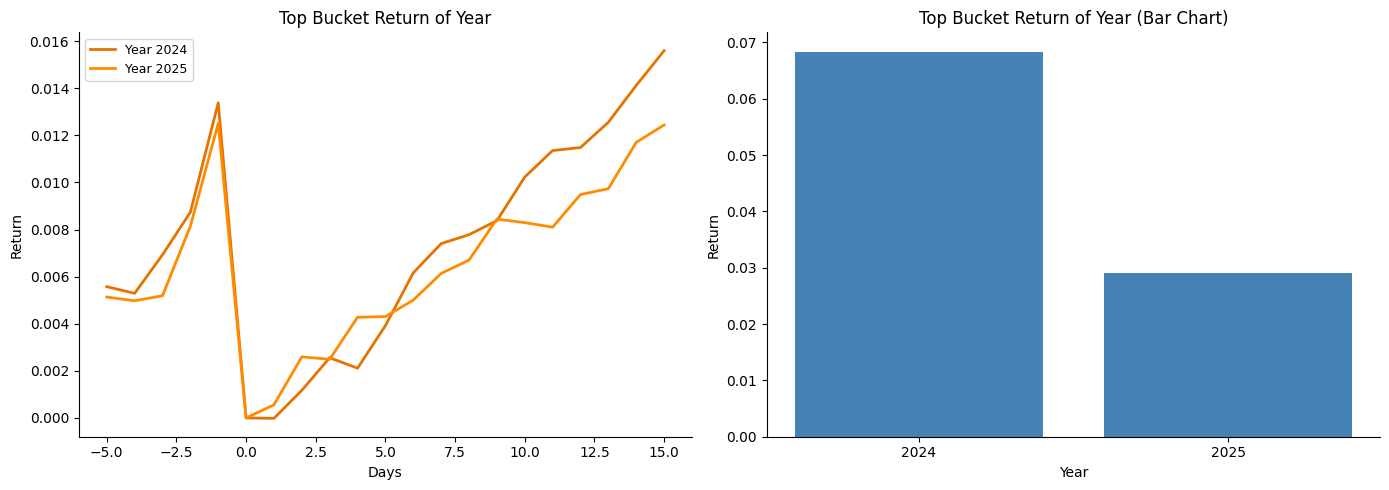

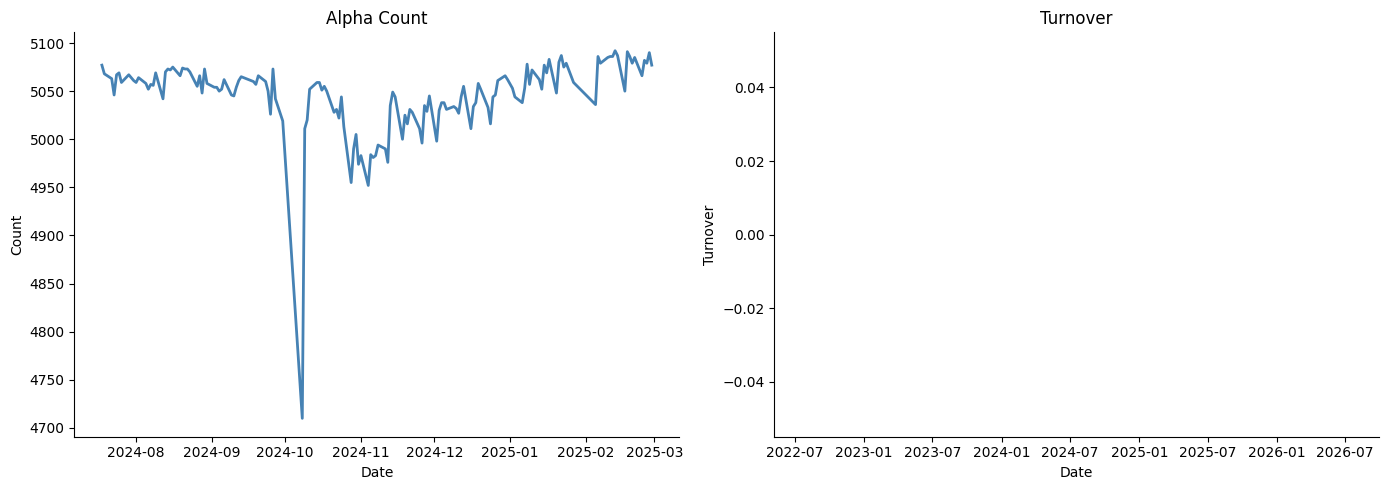

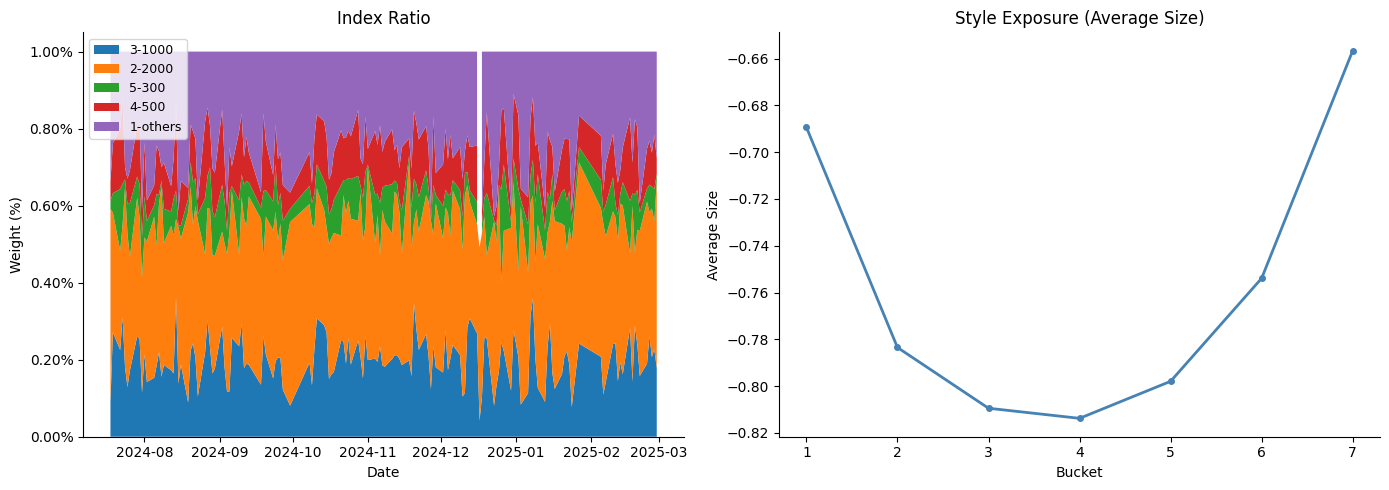

In [15]:
### bt
from sailor_bt_client.event_bt import extend_event
from sailor_bt_client.event_bt import (
    BacktestReturnType,
    BenchmarkMethod,
    EventBacktestBenchmark,
    EventBacktestConfig,
    PlotOption
)
from sailor_bt_client.entry import run_event_bt

# 回测配置
config = EventBacktestConfig(
    time="10:00:00",
    start_date="2024-07-18",
    end_date="2025-03-01",
    ret_type=BacktestReturnType.CLOSE,
    num_groups=7,
    benchmark=EventBacktestBenchmark(
                universe="500",
                method=BenchmarkMethod.INDEX,
            ),
    plot_option=PlotOption(plot_in_notebook=True, pdf_save_dir='./bt_report'),
)

data=run_event_bt(alpha_fdf, config)